# Lecture 2a: Linear Regression and K-Nearest Neighbors
Notebook Lecture 2a

*Data Science in Auditing - Nyenrode*

***

# Linear Regression Example: Predicting Housing Prices

**Scenario:** Predicting house prices based on size and age.

**Data Variables:**
- `price`: Dependent variable (Price of the house in thousands of dollars).
- `size`: Independent variable (Size of the house in square feet).
- `age`: Independent variable (Age of the house in years).

**Linear Regression Model:**
price = β0 + β1 × size + β2 × age

Where:
- β0 is the intercept.
- β1 is the coefficient for size.
- β2 is the coefficient for age.

**Hypothetical Coefficients (after analysis):**
- β0 = 50 (Intercept)
- β1 = 0.1 (Coefficient for size)
- β2 = -5 (Coefficient for age)

**Regression Equation:**
price = 50 + 0.1 * size - 5 * age

**Example Predictions:**

- **2000 sq ft, 5 years old house:**
  Price = 50 + 0.1 * 2000 - 5 * 5 = 225
  
  Predicted Price: $225,000

- **1500 sq ft, 10 years old house:**
  Price = 50 + 0.1 * 1500 - 5 * 10 = 150

  Predicted Price: $150,000

**Interpretation of Coefficients:**
- β1 = 0.1: Each additional square foot increases price by $100.

- β2 = -5: Each additional year in age decreases price by $5,000.


# 2. Linear Regression: Exercises

### 2.1. Importing data

Q2.1.1. Download the _Staten_Island_housing_market_case.xlsx_ file from Canvas and save it to a folder of your choice. **IMPORTANT! Make sure to save the file under the name "Staten_Island_housing_market_case".** 

Q2.1.2 Once the dataset is saved, upload it to your Google Colab files, using the right most _Upload_ button, as shown in the screenshot below:

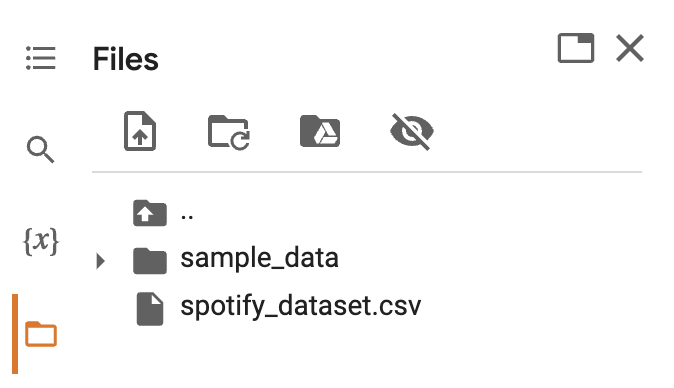



Q2.1.3. Import the pandas and os Python library and read in the _Staten_Island_housing_market_case.xlsx_ file.

In [1]:
#A2.1.3)
import pandas as pd
import os
staten_island_df = pd.read_excel(os.path.join(os.getcwd(), "Staten_Island_housing_market_case.xlsx"))

Q2.1.4. Having missing values in your dataset is a problem for a lot of statistical and machine learning models. There, let's first get rid of missing values in the dataset by dropping them. Can you tell how many rows were deleted? Hint: use the function dropna() and the function len().

In [2]:
# Drop all rows with missing values from the dataframe
#A2.1.4)
print(len(staten_island_df))
staten_island_df = staten_island_df.dropna()
print(len(staten_island_df))

47901
47886


Q2.1.5. Let's create a smaller subset of the dataframe of the first 50 sold houses and name this new dataframe SI_df_small. We create this smaller dataframe so it will be easier to visualize the results.

In [3]:
# Create a subset of the first 50 sold houses called 'SI_df_small'
#A2.1.5)
SI_df_small = staten_island_df.iloc[:50]
SI_df_small

,Sale_id,bbl_id,year,nbhd,bldg_ctgy,tax_cls_p,block,lot,zip,res_unit,...,auth_search,quarter,month,Unemployment_rate,Mortgage_rate,gdp,real_estate_output,days_since_start_datset,days_since_lehman_brothers,days_since_hurricane_sandy
0,82905,553954,2013,ANNADALE,01 ONE FAMILY HOMES,1,5395,4,10312,1,...,True,Q_3,August,7.2,4.4560,15641.3,2782.6,3889,1806,301
1,82906,5539926,2013,ANNADALE,01 ONE FAMILY HOMES,1,5399,26,10312,1,...,True,Q_4,October,7.2,4.1920,15793.9,2782.6,3947,1864,359
2,82907,5540110,2013,ANNADALE,01 ONE FAMILY HOMES,1,5401,10,10312,1,...,True,Q_1,February,7.7,3.5325,15491.9,2782.6,3690,1607,102
3,82916,5620529,2013,ANNADALE,01 ONE FAMILY HOMES,1,6205,29,10312,1,...,True,Q_4,November,6.9,4.2550,15793.9,2782.6,3963,1880,375
4,82922,5621120,2013,ANNADALE,01 ONE FAMILY HOMES,1,6211,20,10312,1,...,True,Q_2,June,7.5,4.0700,15521.6,2782.6,3819,1736,231
6,82925,5621539,2013,ANNADALE,01 ONE FAMILY HOMES,1,6215,39,10312,1,...,True,Q_4,November,6.9,4.2550,15793.9,2782.6,3975,1892,387
7,82929,5621633,2013,ANNADALE,01 ONE FAMILY HOMES,1,6216,33,10312,1,...,True,Q_4,December,6.7,4.4575,15793.9,2782.6,4004,1921,416
8,82930,5621916,2013,ANNADALE,01 ONE FAMILY HOMES,1,6219,16,10312,1,...,True,Q_2,May,7.5,3.5360,15521.6,2782.6,3777,1694,189
9,82933,5622061,2013,ANNADALE,01 ONE FAMILY HOMES,1,6220,61,10312,1,...,True,Q_3,September,7.2,4.4900,15641.3,2782.6,3905,1822,317
10,82937,56226123,2013,ANNADALE,01 ONE FAMILY HOMES,1,6226,123,10312,1,...,True,Q_4,December,6.7,4.4575,15793.9,2782.6,4015,1932,427


Q2.1.6. Often you need to pre-process the data before you can do the analysis you want. For example by 'engineering' a new feature and adding it to the dataset. If you want to know the effect of the 'age' of a house on 'price', you need to create that variable first. Let's create a new 'age' column in the dataset by subtracting the values in the 'yr_built' column from the 'year' column.

In [4]:
# Create the variables 'price' and 'age' with this small data set
#A2.1.6)
SI_df_small['age'] = SI_df_small['year'] - SI_df_small['yr_built']
SI_df_small

/var/folders/gn/cknp6l195b5dgr2xl72flsrr0000gn/T/ipykernel_95424/1392894536.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SI_df_small['age'] = SI_df_small['year'] - SI_df_small['yr_built']


,Sale_id,bbl_id,year,nbhd,bldg_ctgy,tax_cls_p,block,lot,zip,res_unit,...,quarter,month,Unemployment_rate,Mortgage_rate,gdp,real_estate_output,days_since_start_datset,days_since_lehman_brothers,days_since_hurricane_sandy,age
0,82905,553954,2013,ANNADALE,01 ONE FAMILY HOMES,1,5395,4,10312,1,...,Q_3,August,7.2,4.4560,15641.3,2782.6,3889,1806,301,33
1,82906,5539926,2013,ANNADALE,01 ONE FAMILY HOMES,1,5399,26,10312,1,...,Q_4,October,7.2,4.1920,15793.9,2782.6,3947,1864,359,53
2,82907,5540110,2013,ANNADALE,01 ONE FAMILY HOMES,1,5401,10,10312,1,...,Q_1,February,7.7,3.5325,15491.9,2782.6,3690,1607,102,33
3,82916,5620529,2013,ANNADALE,01 ONE FAMILY HOMES,1,6205,29,10312,1,...,Q_4,November,6.9,4.2550,15793.9,2782.6,3963,1880,375,27
4,82922,5621120,2013,ANNADALE,01 ONE FAMILY HOMES,1,6211,20,10312,1,...,Q_2,June,7.5,4.0700,15521.6,2782.6,3819,1736,231,27
6,82925,5621539,2013,ANNADALE,01 ONE FAMILY HOMES,1,6215,39,10312,1,...,Q_4,November,6.9,4.2550,15793.9,2782.6,3975,1892,387,58
7,82929,5621633,2013,ANNADALE,01 ONE FAMILY HOMES,1,6216,33,10312,1,...,Q_4,December,6.7,4.4575,15793.9,2782.6,4004,1921,416,19
8,82930,5621916,2013,ANNADALE,01 ONE FAMILY HOMES,1,6219,16,10312,1,...,Q_2,May,7.5,3.5360,15521.6,2782.6,3777,1694,189,9
9,82933,5622061,2013,ANNADALE,01 ONE FAMILY HOMES,1,6220,61,10312,1,...,Q_3,September,7.2,4.4900,15641.3,2782.6,3905,1822,317,10
10,82937,56226123,2013,ANNADALE,01 ONE FAMILY HOMES,1,6226,123,10312,1,...,Q_4,December,6.7,4.4575,15793.9,2782.6,4015,1932,427,53


In [5]:
# we import the library statsmodels 
import statsmodels.api as sm

"statsmodels (often referred to as sm) is a powerful Python library used for statistical modeling and analysis. One of its key functions is to help us build and understand linear regression models. Linear regression is a way to predict a dependent variable (like 'price') using one or more independent variables (like 'age'). For morel information about statsmodels please see here: https://www.statsmodels.org/stable/index.html

When we create a linear regression model, it's important to include a 'constant' or 'intercept.' This intercept is a starting point for the regression line and represents the expected value of the dependent variable when all independent variables are zero.

In Python, using statsmodels, we add this constant to our model with the sm.add_constant() function. This function essentially adds an additional column of ones to our data, representing the constant. For more information please see here: https://www.statsmodels.org/devel/generated/statsmodels.tools.tools.add_constant.html

Q2.1.7) Create a dataframe called X that includes our independent variable for the regression, and also the constant. In this case, we are interested in understanding how 'age' affects 'price'. So, X will consist of the 'age' data from our dataset and 'const', a column of ones representing the constant. Hint: you need to use the ```sm.add_constant()``` function. 

In [6]:
#A2.1.7)
X = sm.add_constant(SI_df_small['age'])
X

,const,age
0,1.0,33
1,1.0,53
2,1.0,33
3,1.0,27
4,1.0,27
6,1.0,58
7,1.0,19
8,1.0,9
9,1.0,10
10,1.0,53


In a linear regression model, we have two main types of variables: independent variables and a dependent variable. The independent variables (which we just set up in X) are what we think might influence the dependent variable. The dependent variable is what we are trying to predict or explain.

Now that we have our independent variable X (which includes 'age' and the constant), it's time to identify our dependent variable y. In the context of our study, we want to predict 'price' based on the 'age'. Therefore, please use 'price' as our dependent variable.

Q2.1.8) Create a dependent variable ```y``` and fill it with the values of ```price```.

In [7]:
#A2.1.8)
y = SI_df_small['price']
y

0     775000.0
1     630000.0
2     705000.0
3     285000.0
4     358000.0
6     580000.0
7     355000.0
8     400000.0
9     360000.0
10    225000.0
11    722957.0
12    636250.0
13    125000.0
14    458000.0
15    655000.0
16    605000.0
17    915000.0
18    325000.0
19    507000.0
20    500000.0
21    595676.0
22    525000.0
23    485000.0
25    865000.0
26    690000.0
27    540000.0
28    558500.0
29    481500.0
30    520000.0
31    715000.0
32    745000.0
33    735000.0
34    755000.0
35    875000.0
36    672000.0
37    180000.0
38    220000.0
39    945000.0
40    700000.0
41    672045.0
42    700000.0
43    705000.0
44    635000.0
45    655000.0
46    560000.0
47    670000.0
54    435000.0
55    575311.0
56    445000.0
57    461370.0
Name: price, dtype: float64

We've set up our independent variables X (which includes 'age' and a constant) and our dependent variable y (the 'price'). The next step is to build and train our linear regression model.

This is done with sm.OLS(y, X).fit(), which is a compact but powerful line of code in Python:

- sm.OLS(y, X): This creates the linear regression model using statsmodels. We tell the model that y (house prices) is what we want to predict, and X (ages of the houses, plus a constant) is the data we're using for prediction.

- .fit(): This method 'fits' the model to our data. It calculates the best-fitting line through our data points by minimizing the difference between the observed prices and the prices predicted by our model.

The result, stored in linreg, is our trained model, ready for analysis and prediction. It encapsulates the relationship between the ages of houses and their prices.

After training the model, we use linreg.summary() to get a summary of our model's performance and statistics.

The summary() method provides a detailed report of the model, including:

- The coefficients of the model: These tell us the impact of each independent variable on the dependent variable.
- The R-squared value: This indicates how well our independent variables explain the variation in the dependent variable.
- p-values and confidence intervals for the coefficients: These help us understand the statistical significance of each independent variable.

In [8]:
linreg = sm.OLS(y, X).fit()
print(linreg.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     7.999
Date:                Tue, 21 Nov 2023   Prob (F-statistic):            0.00681
Time:                        12:35:49   Log-Likelihood:                -674.02
No. Observations:                  50   AIC:                             1352.
Df Residuals:                      48   BIC:                             1356.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.628e+05   4.16e+04     15.940      0.0

Q2.1.9. Now that we have the summary of the linear regression of housing price given age, we can interpret the results. Please answer the following questions:

- (A) If 'age' increases by one year, how does that affect the predicted 'price', according to this model?
- (B) Given the intercept and 'age' coefficient, what would be the predicted 'price' for a house that is newly built (age = 0)?
- (C) What does the p-value for 'age' indicate about its significance in predicting 'price'?
- (D) What does the R-squared value inform us about this model's fit?

A2.1.9)

(A) For each additional year of 'age', the predicted 'price' decreases by approximately $2,836.82.
This is indicated by the negative coefficient of 'age' in the regression model.

(B) When 'age' is 0 (for a newly built house), the predicted 'price' would be equal to the intercept.
The model predicts the price to be approximately $662,800, which is the value of the intercept.

(C) The p-value for 'age' is 0.007, which is less than the common significance level of 0.05.
This suggests that 'age' is statistically significant in predicting the 'price'.
In other words, there is strong evidence to believe that 'age' has a meaningful association with 'price'.

(D) The R-squared value is 0.143, which means that approximately 14.3% of the variation in 'price' can be explained by the 'age' of the house.
This is relatively low, indicating that 'age' alone does not account for most of the variability in 'price',
and there may be other factors at play that affect the 'price' of a house.


Q2.1.10) The general formula for a linear regression with one variable is: y =  b0 + b1x1:

- y is the predicted variable, in this case price.
- b0 is the intercept.
- b1 is the coefficient or slope of the line for variable x1.
- x1 is the value for variable x1.

Please fill in the intercept, coefficient and x1 value for a house that is 50 years old. Write down this filled formula and explain it. What is the predicted price for this house, according to this model?

A2.1.10)
y = b0 + b1x1

predicted_price = intercept + (coefficient_age * age_value)

predicted_price = 662800 + (-2836.8160 * 50)

predicted_price = $ 520959.2

# 3. Visual understanding of linear regression:

It's always a good idea to have a look at your data to interpret you statistical results, so if it all adds up. In the code that is displayed next we create a scatterplot that displays ```age``` versus ```price```.

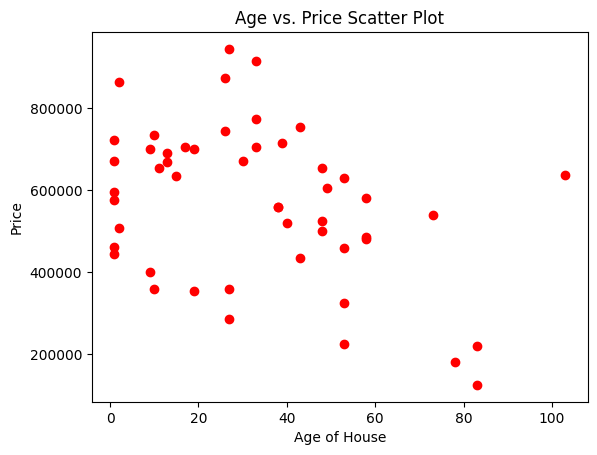

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming SI_df_small and linreg are already defined as per previous steps

# Plot the "age" and "price" in a scatter plot
plt.scatter(SI_df_small['age'], SI_df_small['price'], color='red')  # s is the size of the points

# Adding titles and labels for clarity
plt.title('Age vs. Price Scatter Plot')
plt.xlabel('Age of House')
plt.ylabel('Price')

# Display the plot
plt.show()


Q3.1 Looking at the scatter plot above, please answer the following questions:

- (A) How would you draw the line that best visualizes the relationship between the two variables?
- (B) How does this work? How does Python find the best line?

A3.1) 
A) I would probably go from the topleft to the bottomright.

B) This is often done by looking for the line that minizes the sums of squares. 

Let's have a look at the regression line in the scatterplot. We redo the plot in a slightly different way as to include the regression line.

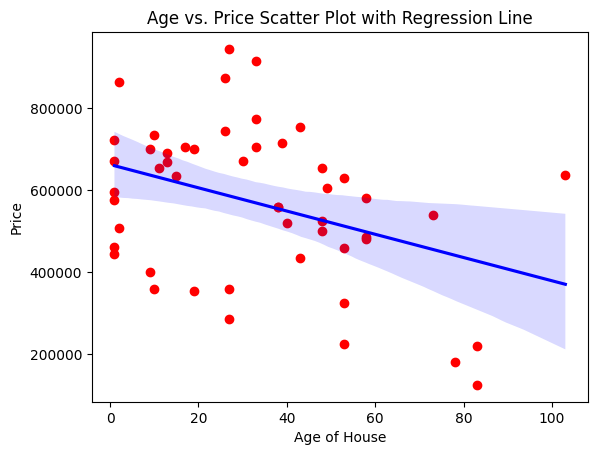

In [10]:
# Plot the "age" and "price" in a scatter plot
plt.scatter(SI_df_small['age'], SI_df_small['price'], color='red')  # s is the size of the points

# To visualize the best-fitting line, you can use seaborn's regplot which combines scatter plot and regression line
sns.regplot(x='age', y='price', data=SI_df_small, scatter=False, color='blue')

# Adding titles and labels for clarity
plt.title('Age vs. Price Scatter Plot with Regression Line')
plt.xlabel('Age of House')
plt.ylabel('Price')

# Display the plot
plt.show()

Q3.2) Looking at the scatterplot with regression line above, answer the following questions:

- (A) Do the intercept and coeffient align with the intercept given in the coefficients table of the regression of questions x?
- (B) What measure does a computer (Python) use to distinguish between a good and badly fitted line?

A3.2)
(A) Yes, the visual intercept and coefficient (slope of the line) are identical to the ones in the regression table.
(B) An evaluation metric, such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE) or Mean Absolute Error (MAE).

# 4 Regression with multiple variables

Often regression is performed with many more variables (often called features) to model the more complex relations that can occur in the data. In this case, let's have a look at many more variables and put them in our model, and fit the relationship of all those features on the price of a house. Study the code below and see if it makes sense to you.

In [11]:
# Assuming staten_island_df is your DataFrame and it's been preprocessed

# Selecting the features for the regression model
features = ['sale_date', 'land_sqft', 'tot_sqft', 'yr_built', 'long', 'lat', 'atm', 'bank', 'bar', 'book_store',
            'bus_station', 'cafe', 'church', 'city_hall', 'doctor', 'fire_station', 'gas_station',
            'gym', 'hospital', 'library', 'lodging', 'mosque', 'movie_theater', 'museum', 'night_club',
            'park', 'parking', 'police', 'restaurant', 'school', 'shopping_mall', 'store', 'supermarket',
            'train_station']

# Adding the constant term for the intercept
X = sm.add_constant(staten_island_df[features])

# Defining the dependent variable
y = staten_island_df['price']

# Fitting the model
multivar_linreg = sm.OLS(y, X).fit()

# Printing the summary of the model
print(multivar_linreg.summary())


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.471
Method:                 Least Squares   F-statistic:                     1256.
Date:                Tue, 21 Nov 2023   Prob (F-statistic):               0.00
Time:                        12:37:14   Log-Likelihood:            -6.3036e+05
No. Observations:               47886   AIC:                         1.261e+06
Df Residuals:                   47851   BIC:                         1.261e+06
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          4.602e+07   2.16e+06     21.312

Q4.1) Look at the regression table that is outputted above and answer the following questions:

- (A) Which variable has the largest impact on price? How should that be interpreted?
- (B) And which variable has the smallest impact on price? How should that be interpreted?


A4.1)

(A) Latitude has the biggest impact with a coefficient of -6.914*10^5 (-691400 for every degree in latitude).
Latitude measures the difference in location on the scale North-South axis. A higher latitude number means the property is further north.
The negative coefficient indicates that properties further north are associated with a decrease in price, given all other variables are held constant.
This means that the southern part of Staten Island probably has more expensive houses than the nortern part of the island.

(B) The sale_date coefficient of 9.2801 indicates a slight upward trend in property prices over time.
This suggests that each day later in the dataset is associated with an increase in the sale price of approximately 9.28 dollars.
Over the course of a year (365 days), this would translate to an increase of roughly 3,387 dollars (9.28 * 365).

For an auditor it is important to always interpret coefficients and challenge them. In the regression table it states that for every extra supermarket within 500m, property prices drop by 6395 dollar. Let's run the code below and investigate why this might be the case.

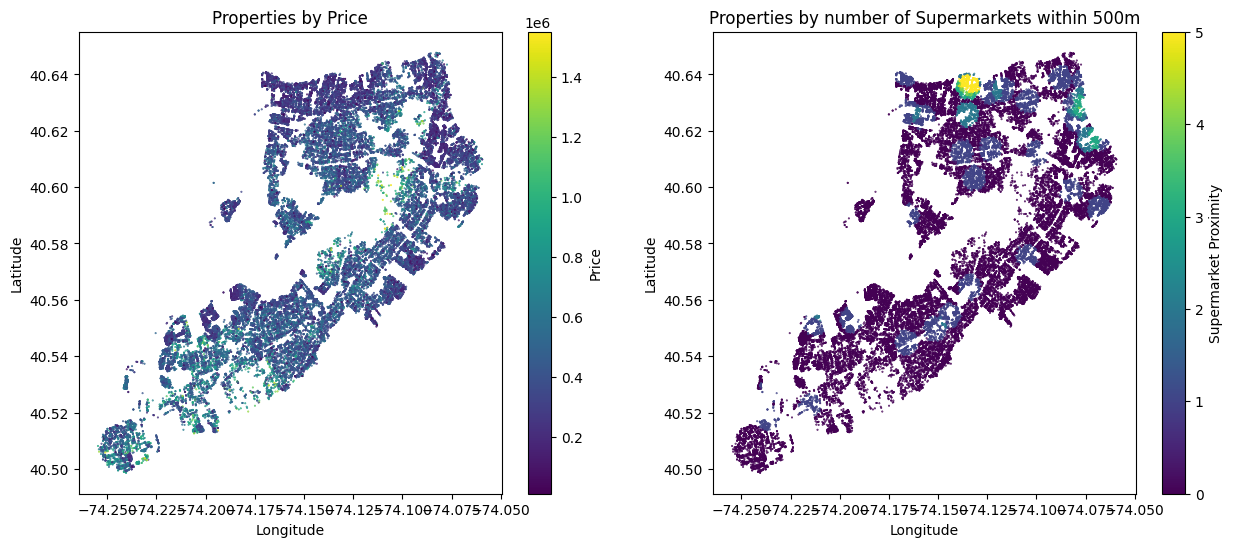

In [12]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot for price
scatter1 = ax1.scatter(staten_island_df['long'], staten_island_df['lat'], c=staten_island_df['price'], s=0.2, cmap='viridis')
ax1.set_title('Properties by Price')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
# Adding a colorbar for the first plot
plt.colorbar(scatter1, ax=ax1, orientation='vertical', label='Price')

# Scatter plot for supermarkets
scatter2 = ax2.scatter(staten_island_df['long'], staten_island_df['lat'], c=staten_island_df['supermarket'], s=0.2, cmap='viridis')
ax2.set_title('Properties by number of Supermarkets within 500m')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
# Adding a colorbar for the second plot
plt.colorbar(scatter2, ax=ax2, orientation='vertical', label='Supermarket Proximity')

# Show the plots
plt.show()

Q4.2) If you take a good look at the two maps. Do you think that the regression coefficient for supermarket makes sense? Why / why not? Based on the maps, why do you think number of supermarkets is negatively correlated with housing price?

A4.2) 
The tricky thing about correlations is that the human brain can always come up with a story why something leads to a higher or lower housing price. You could say that people prefer not to live in a busy shopping street next to a super market and that is why the the amount of supermarkets correlate negatively with housing price.

However, when we look at the two maps, we see a different story.
On the left map, we see expensive neighborhoods (yellow dots) and cheap neighborhoods (dark blue / purple dots).
On the right map, we see the sold houses that have no supermarkets (purple dots) or at least one supermarket within 500m (blue, green, yellow dots).
From these two maps we learn that supermarkets are never situated in neighborhoods with very expensive houses (villa's).
At the same time there are 5 supermarkets located in one of the cheapest neighborhood of Staten Island.
Therefore, it makes sense that supermarkets are negatively correlated with amount of supermarkets within 500m. 
However, it's very important to realise that these are indeed correlations, not causation. Meaning that prices will not necessarily not drop in a villa neighborhood once you decide to build a supermarket there.

Q4.3) As a auditor for a real estate agency, your task is to identify potential anomalies in property valuations. Using a multivariate linear regression model, you've predicted house prices based on various features. Now, to ensure the accuracy of your model and identify any outliers or unusual cases, you need to examine the houses where the model's predictions deviate significantly from the actual sale prices. Your goal is to find the top 10 houses with the largest differences between the predicted price and the actual sale price, specifically focusing on houses that sold under 100,000 dollars. Look up some of these anomalies on Google Street View using the coordinates. To what extent do these look like houses that sell under 100,000 dollars? What do you think about that as auditor?

We do this by applying the predict() function. What this function does is take the model that was fitted, input the independent variable of choice (in our case here ```X```), and predicts new dependent variables based on the inputted data. 

In [13]:
# Calculating predicted prices for the entire dataset
staten_island_df['predicted_price'] = multivar_linreg.predict(X)

# Computing the absolute difference between actual and predicted prices
staten_island_df['price_difference'] = abs(staten_island_df['price'] - staten_island_df['predicted_price'])

# Applying the filter for houses priced under $100,000 and sorting the DataFrame based on the differences
# Then selecting the top 10
top_10_differences = staten_island_df[staten_island_df['price'] < 100000].sort_values(by='price_difference', ascending=False).head(10)

# Selecting specific columns for display
top_10_differences = top_10_differences[['lat', 'long', 'price', 'predicted_price', 'price_difference']]

# Displaying the top 10 houses
top_10_differences

,lat,long,price,predicted_price,price_difference
30777,40.534636,-74.200793,30000.0,939592.201277,909592.201277
27840,40.527132,-74.176004,60600.0,931901.316725,871301.316725
8103,40.505936,-74.239558,26000.0,859203.258751,833203.258751
19084,40.530480,-74.183477,65000.0,827943.996456,762943.996456
41511,40.541337,-74.195783,40000.0,802774.050416,762774.050416
11841,40.541350,-74.193070,45000.0,805779.472583,760779.472583
32450,40.529451,-74.205810,25000.0,734245.131473,709245.131473
34758,40.633017,-74.147172,71000.0,767342.507568,696342.507568
41721,40.514504,-74.193741,90000.0,774447.160718,684447.160718
28366,40.535761,-74.155042,79557.0,742305.810598,662748.810598


Q4.3) No real right or wrong answers here, but it seems like these houses are indeed sold under the price.

# 5. KNN: Theory

Please read the section **"Understanding K-Nearest Neighbors (KNN)" in the Cheatsheet 2a**, before continuing with the next questions.

# 6. KNN: Exercises

As an auditor you have to check the portfolio of a real estate client. You are checking to what extent some houses are eligble for certain tax deductions. One of the things you need to check is if properties labeled as "TWO FAMILY HOMES" are indeed two family homes. Normally you would either check all these rows manually or check a sample and use statistics to determine if your sample findings can be generalized to the population. However, now you learned a new trick to track down the properties that might be mislabeled using machine learning! You will train a KNN model to predict building category classes and check predicted class vs label. The ones where predicted class and label differ, should be checked manually, because they have the highest chance of being wrongly labeled.

Q6.1. First we will visualize the different building categories on two axes: price and total square feet. Looking at the scatter plot, to what extent do you think KNN can be used to correctly predict the building category using price and total square feet?

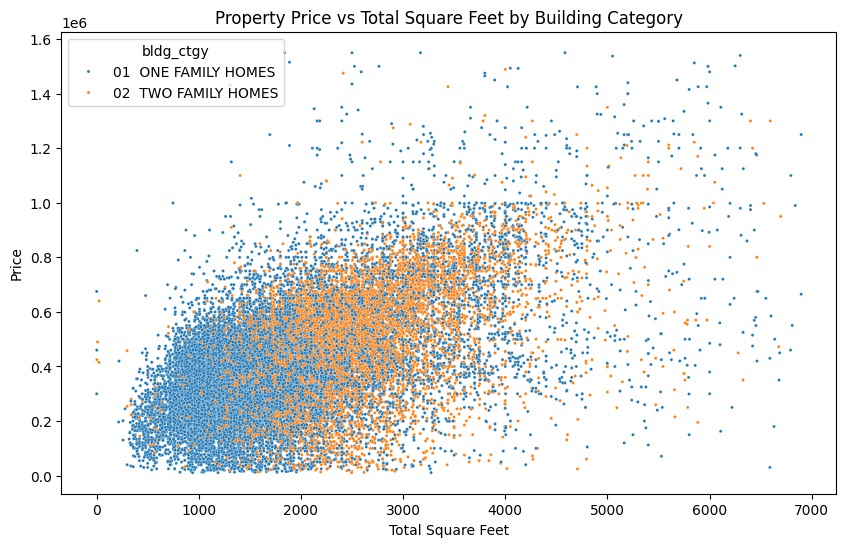

In [14]:
# Drop three family homes from the dataset
staten_island_df = staten_island_df[staten_island_df.bldg_ctgy != '03  THREE FAMILY HOMES']

# Creating a scatterplot with price and total square footage, colored by building category
plt.figure(figsize=(10, 6))
sns.scatterplot(data=staten_island_df, x='tot_sqft', y='price', hue='bldg_ctgy', s=5)
plt.title('Property Price vs Total Square Feet by Building Category')
plt.xlabel('Total Square Feet')
plt.ylabel('Price')
plt.show()

A6.1 
There seem to be 2 relatively distinct groups. However, there is also quite some overlap between the groups, so it will not be easy to separate them using KNN.

Now we want to fit a knn model on the data to investigate how well that method performs. In order to do that, we make use of the sklearn package. 

- _sklearn_: is a package that is used for machine learning in Python. For more information see here: https://scikit-learn.org/stable/
- _KNeighborsClassifier_: contains the knn classifier that we will be using. For more information see here: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
- _MinMaxScaler_: is a scaling function that transform features by scaling each feature to a given range. For more information see here: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html
- _classification_report_: Builds a text report showing the main classification metrics. For more information see here: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
- _confusion_matrix_: Computes a confusion matrix to evaluate the accuracy of a classification. For more information see here: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
- _fit_transform_: Fits a model to data, then transforms the data. For more information see here: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

Then we select 'tot_sqft' and 'price' as features to predict building category. Then use normalization (min-max scaling) to scale the features. Please run the code.

In [16]:
# Selecting relevant features and the target variable
features = ['tot_sqft', 'price']
target = 'bldg_ctgy'

# Filtering the dataset for the two building categories and the selected features
X = staten_island_df[features]
y = staten_island_df[target]

# Normalizing the feature data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[0.33009427, 0.49653519],
       [0.22146483, 0.40233855],
       [0.29209572, 0.45106095],
       ...,
       [0.44597534, 0.35682273],
       [0.44597534, 0.38334136],
       [0.46526468, 0.35357457]])

Q6.2)
A) Why are all scaled features now values between 0 and 1? 
B) Why is it necessary to scale all features before training a KNN model on them?

A6.2)

(A) When using MinMaxScaler, each feature is scaled linearly to a range between 0 and 1.
The formula used is (X - X_min) / (X_max - X_min), where X is the original value, X_min is the minimum value of that feature in the dataset, and X_max is the maximum value.
This transformation shifts the minimum value of each feature to 0 and the maximum value to 1.
As a result, all other values fall between 0 and 1 proportionally.

(B) Scaling features is essential in KNN because KNN calculates the distance between different instances to make predictions.
If the features are on different scales, then the distance calculations might be dominated by one feature over the others.

The code below is used to train a KNN classifier model with 4 neighbors on the scaled data, and then to create a confusion matrix. 

In [17]:
# Training the KNN model
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_scaled, y)

# Predicting and evaluating the model
y_pred = knn.predict(X_scaled)
conf_matrix = confusion_matrix(y, y_pred)

# The sorted() function sorts the elements of a given iterable in a specific order (ascending or descending) and returns it as a list.
# set() creates a set (and hence removes duplicates)
unique_classes = sorted(set(y))
conf_matrix_df = pd.DataFrame(conf_matrix, index=unique_classes, columns=unique_classes)

# Renaming the index and columns for clarity
conf_matrix_df.index.name = 'Actual'
conf_matrix_df.columns.name = 'Predicted'

conf_matrix_df

Predicted,01 ONE FAMILY HOMES,02 TWO FAMILY HOMES
Actual,,
01 ONE FAMILY HOMES,33245,1213
02 TWO FAMILY HOMES,7231,5726


Q6.3) 
(A) Looking at the confusion matrix, what do you find? To what extent do you think this model is useable to predict building categories? 
(B) What happens if you take 1 neighbor or 150 neighbors? Why do you think that is?

A6.3) 
(A)It is not bad in predicting the building categories, bu definitely not perfect. So, it depends on what you want to use this for in practice, but I would not advise to use this for analysis that are high risk.
(B) with k = 1, model performance improves. Probably this is because houses that are close to each other are likely to be similar. with l = 150, performance decreases for the same reason as before, houses that are close are likely to be similar so with k is large this info is not taken into account.

Q6.4) Visualize predicted building categories vs predicted building categories. Do you see why KNN gets so many predictions wrong?

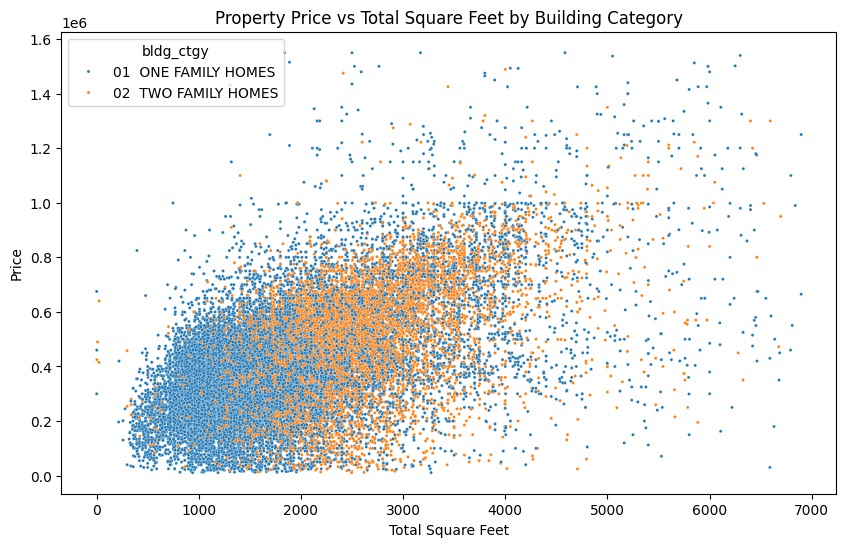

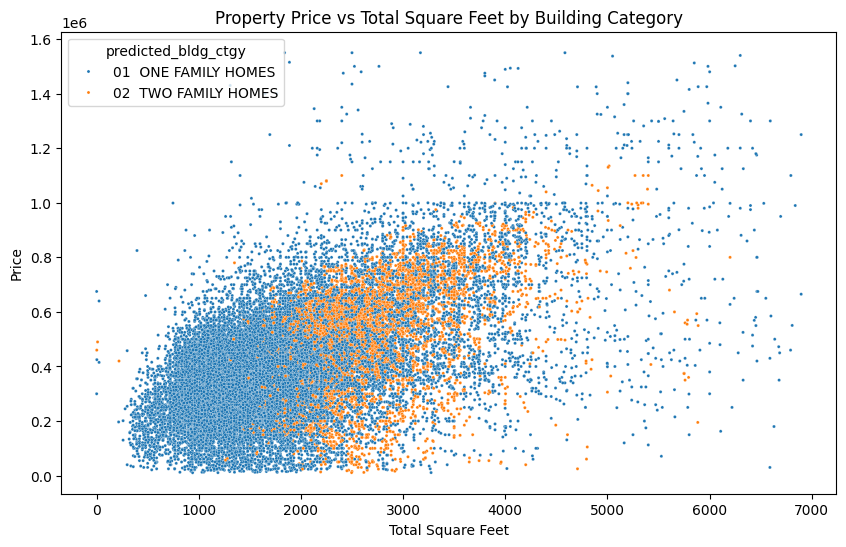

In [18]:
# Drop three family homes from the dataset
staten_island_df = staten_island_df[staten_island_df.bldg_ctgy != '03  THREE FAMILY HOMES']

staten_island_df['predicted_bldg_ctgy'] = knn.predict(X_scaled)

# Creating a scatterplot with price and total square footage, colored by building category
plt.figure(figsize=(10, 6))
sns.scatterplot(data=staten_island_df, x='tot_sqft', y='price', hue='bldg_ctgy', s=5)
plt.title('Property Price vs Total Square Feet by Building Category')
plt.xlabel('Total Square Feet')
plt.ylabel('Price')
plt.show()

# Creating a scatterplot with price and total square footage, colored by predicted building category
plt.figure(figsize=(10, 6))
sns.scatterplot(data=staten_island_df, x='tot_sqft', y='price', hue='predicted_bldg_ctgy', s=5)
plt.title('Property Price vs Total Square Feet by Building Category')
plt.xlabel('Total Square Feet')
plt.ylabel('Price')
plt.show()

A6.4) There is substantial overlap between the two categies of homes wrt the total square feet price. You can see that in the middle part of the plot it is difficult to predict based on these two features.

Q6.5) You want to make sure that no buildings are labeled as 'TWO FAMILY HOMES', while in reality being 'ONE FAMILY HOMES'. Therefore you look at 10 houses that are predicted by KNN to be one family homes based on the data, but are labeled as two family homes. Check some of the houses manually using the coordinates in Google Street View. Do you find any houses that you think are mislabeled? Discuss to what extent this approach offers an alternative to checking everything manually or investigating a sample.

In [19]:
# Filter for cases where the predicted category is "01 ONE FAMILY HOMES" and the actual category is "02 TWO FAMILY HOMES"
specific_mismatches = staten_island_df[(staten_island_df['predicted_bldg_ctgy'] == '01  ONE FAMILY HOMES') & (staten_island_df['bldg_ctgy'] == '02  TWO FAMILY HOMES')]

# Select the first 10 houses from this specific mismatch
top_10_specific_mismatches = specific_mismatches.head(10)

# Displaying the relevant columns for these 10 houses
print(top_10_specific_mismatches[['lat', 'long', 'bldg_ctgy', 'predicted_bldg_ctgy']])

# staten_island_df.bldg_ctgy.value_counts()

           lat       long             bldg_ctgy   predicted_bldg_ctgy
47   40.546364 -74.188403  02  TWO FAMILY HOMES  01  ONE FAMILY HOMES
103  40.641182 -74.099429  02  TWO FAMILY HOMES  01  ONE FAMILY HOMES
148  40.606005 -74.119083  02  TWO FAMILY HOMES  01  ONE FAMILY HOMES
149  40.606902 -74.122960  02  TWO FAMILY HOMES  01  ONE FAMILY HOMES
150  40.606888 -74.122956  02  TWO FAMILY HOMES  01  ONE FAMILY HOMES
152  40.606263 -74.131836  02  TWO FAMILY HOMES  01  ONE FAMILY HOMES
153  40.599761 -74.126955  02  TWO FAMILY HOMES  01  ONE FAMILY HOMES
154  40.598438 -74.127172  02  TWO FAMILY HOMES  01  ONE FAMILY HOMES
157  40.601788 -74.130297  02  TWO FAMILY HOMES  01  ONE FAMILY HOMES
158  40.602285 -74.130399  02  TWO FAMILY HOMES  01  ONE FAMILY HOMES


A6.5) It is useful to only look at outliers, this can save a lot of time!